In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping

from statsmodels.tsa.arima.model import ARIMA

import yfinance as yf
import math
import warnings
warnings.filterwarnings("ignore")

In [37]:
stocks = {
    "Oracle": "ORCL",
    "ICICI": "ICICIBANK.NS",
    "Britannia": "BRITANNIA.NS",
    "Maruti": "MARUTI.NS",
    "AbbottIndia": "ABBOTINDIA.NS"
}


In [38]:
all_stock_data = {}

start_date = "2021-01-01"
end_date = "2025-12-31"

for name, ticker in stocks.items():
    print(f"Downloading data for {name} ({ticker})")

    df = yf.download(ticker, start=start_date, end=end_date)

    # Keep only Close price
    df = df[["Close"]].dropna()

    all_stock_data[name] = df

    print(f"{name}: {df.shape[0]} rows loaded\n")

print("All stocks downloaded successfully")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Oracle: 1254 rows loaded

ICICI: 1235 rows loaded

Britannia: 1235 rows loaded

Maruti: 1235 rows loaded

AbbottIndia: 1235 rows loaded

All stocks downloaded successfully


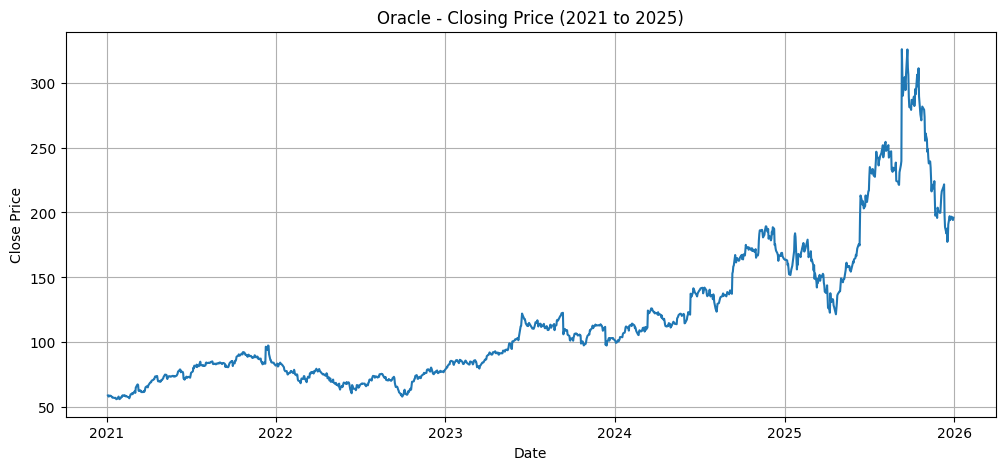

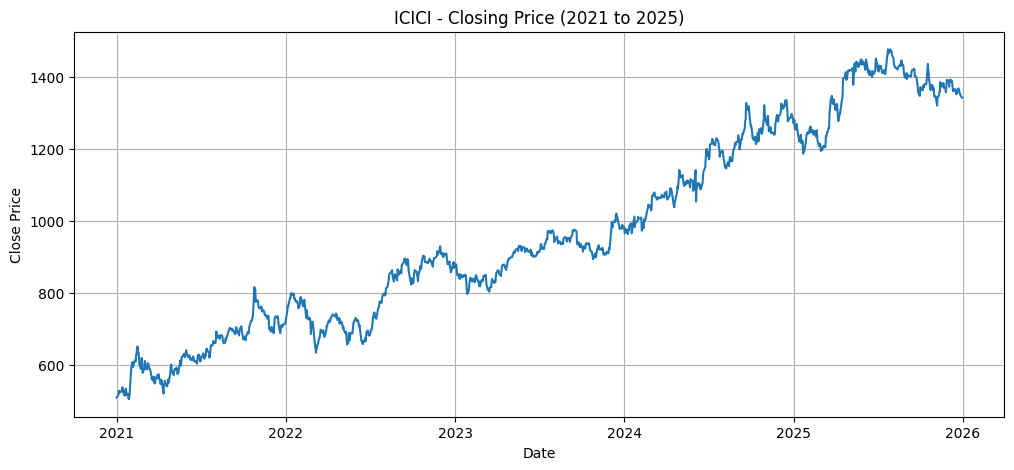

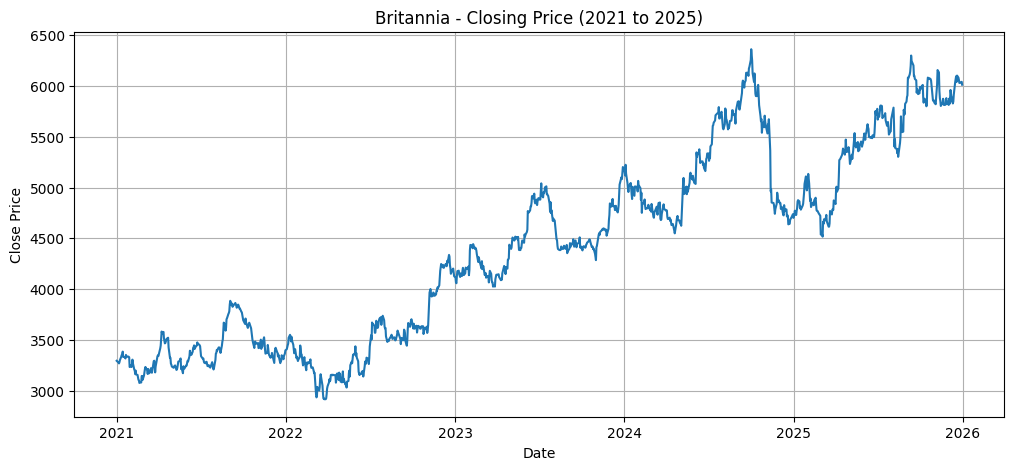

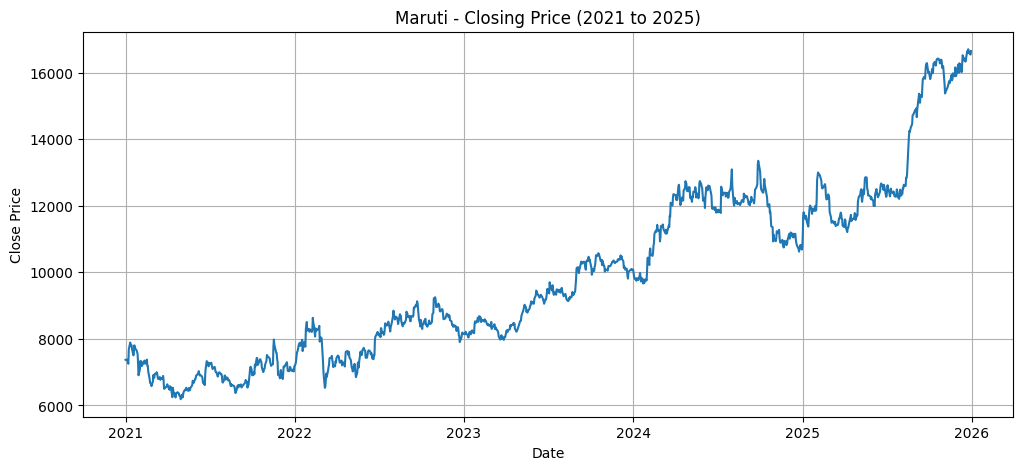

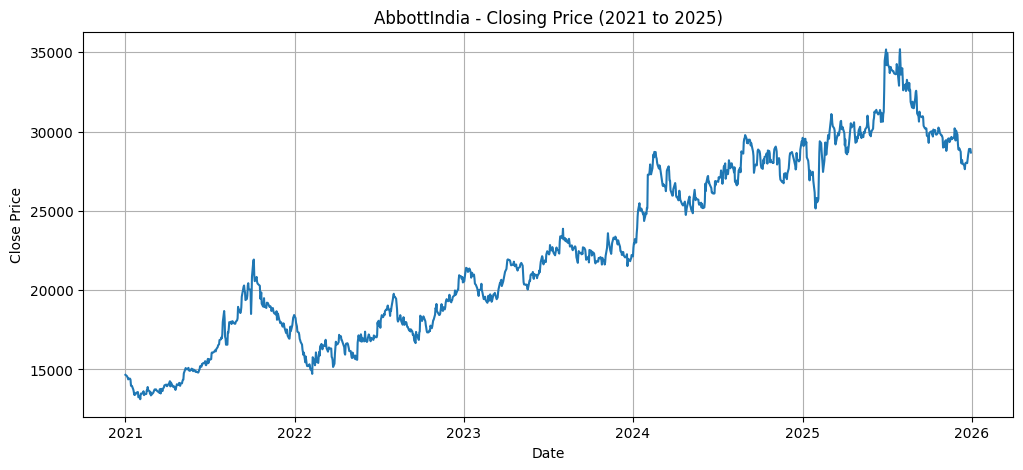

In [39]:
for name, df in all_stock_data.items():
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df["Close"])
    plt.title(f"{name} - Closing Price (2021 to 2025)")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.grid(True)
    plt.show()

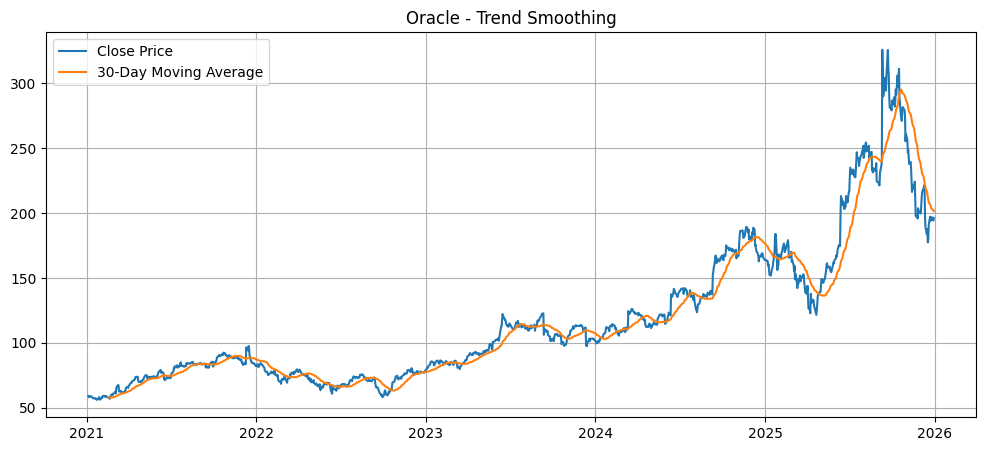

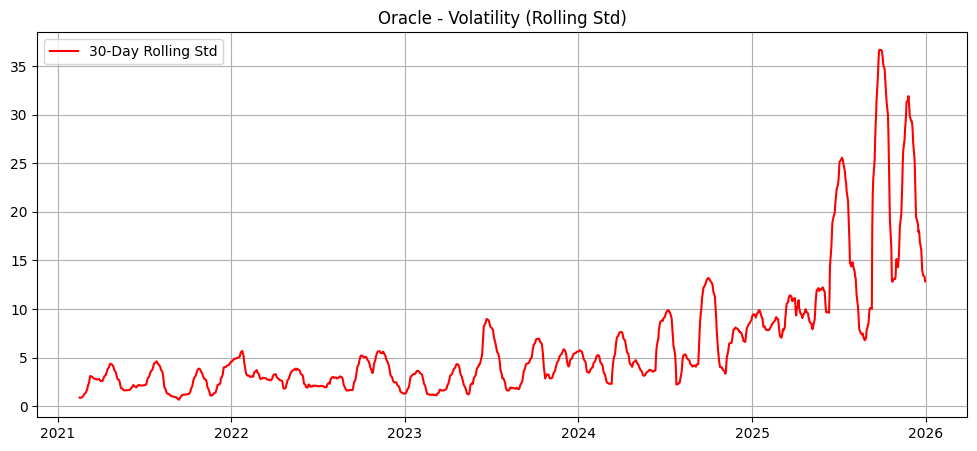

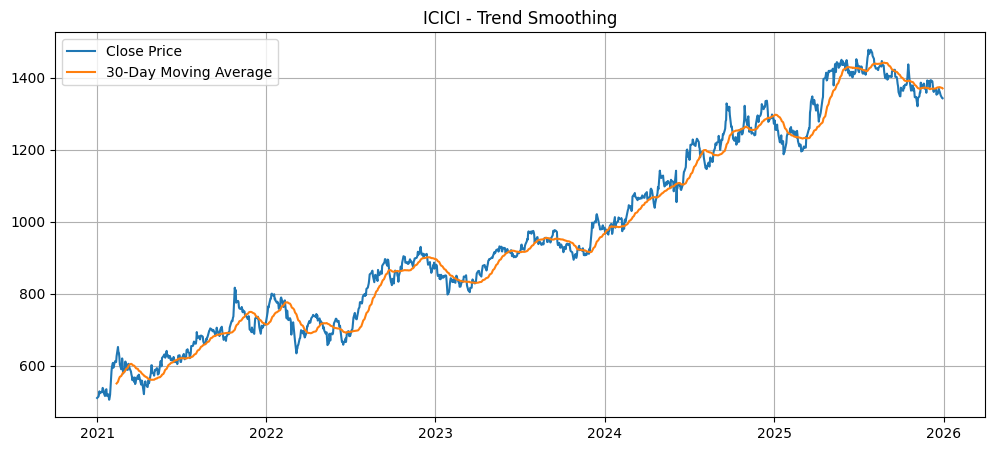

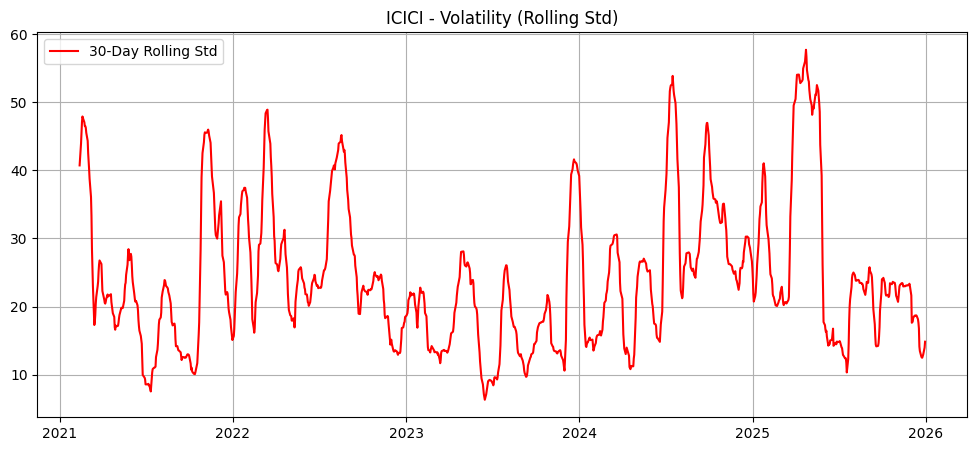

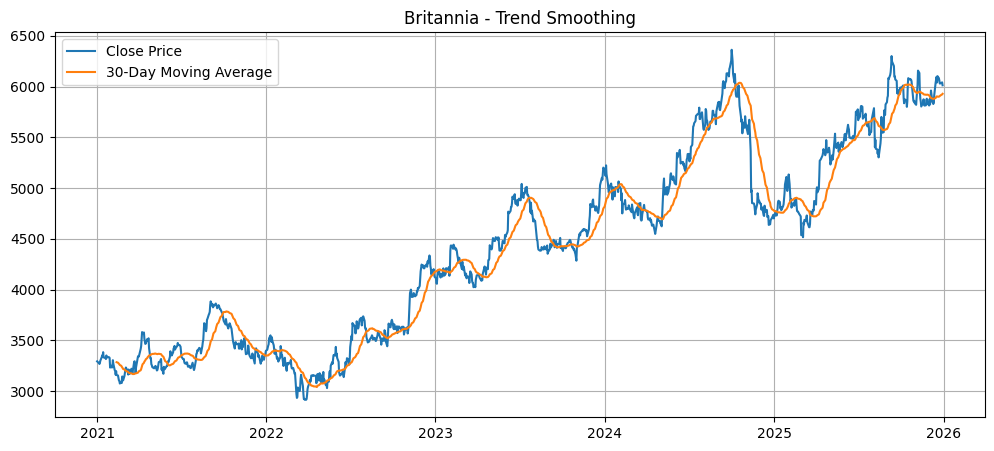

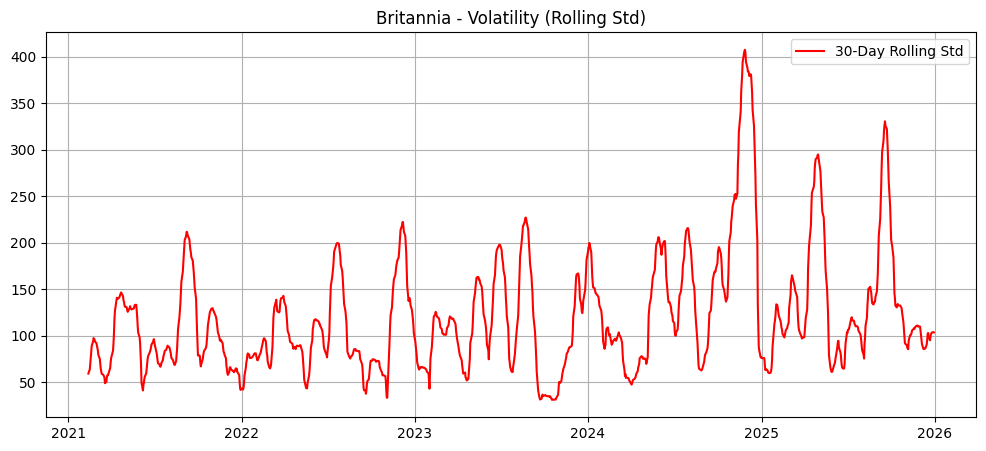

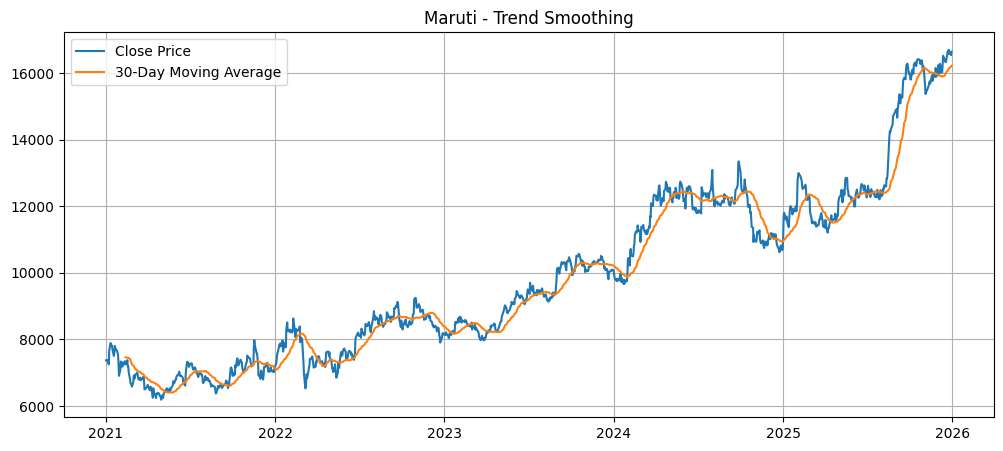

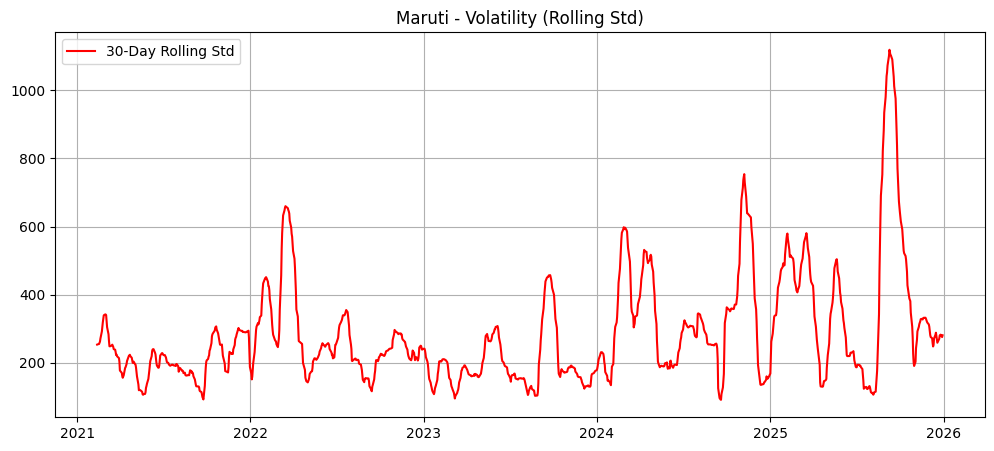

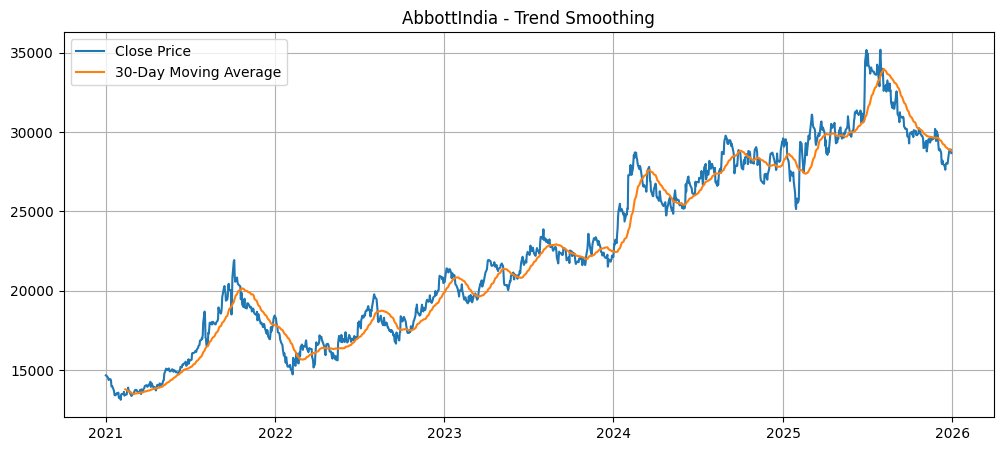

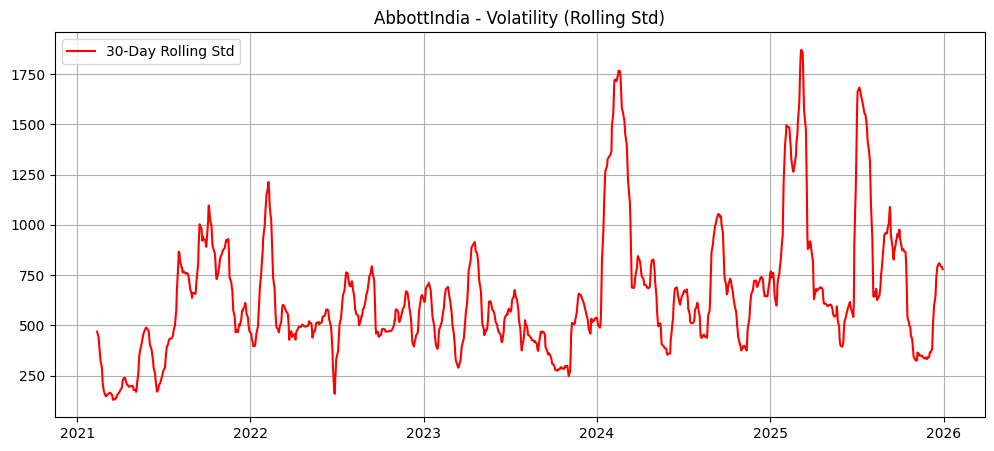

In [40]:
window = 30

for name, df in all_stock_data.items():
    df = df.copy()

    df["Rolling_Mean"] = df["Close"].rolling(window=window).mean()
    df["Rolling_Std"] = df["Close"].rolling(window=window).std()

    all_stock_data[name] = df

    # Plot Rolling Mean
    plt.figure(figsize=(12, 5))
    plt.plot(df["Close"], label="Close Price")
    plt.plot(df["Rolling_Mean"], label="30-Day Moving Average")
    plt.title(f"{name} - Trend Smoothing")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Rolling Std
    plt.figure(figsize=(12, 5))
    plt.plot(df["Rolling_Std"], label="30-Day Rolling Std", color="red")
    plt.title(f"{name} - Volatility (Rolling Std)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [41]:
for name, df in all_stock_data.items():
    df = df.copy()

    # Check missing values
    print(f"\n{name}")
    print("Missing values before:", df.isnull().sum().values)

    # Forward fill (safe for time series)
    df = df.fillna(method="ffill")

    # Backward fill (for initial missing values if any)
    df = df.fillna(method="bfill")

    # Store back
    all_stock_data[name] = df

    print("Missing values after:", df.isnull().sum().values)

print("\nData cleaning completed successfully")


Oracle
Missing values before: [ 0 29 29]
Missing values after: [0 0 0]

ICICI
Missing values before: [ 0 29 29]
Missing values after: [0 0 0]

Britannia
Missing values before: [ 0 29 29]
Missing values after: [0 0 0]

Maruti
Missing values before: [ 0 29 29]
Missing values after: [0 0 0]

AbbottIndia
Missing values before: [ 0 29 29]
Missing values after: [0 0 0]

Data cleaning completed successfully


In [42]:
for name, df in all_stock_data.items():
    print("\n" + "="*50)
    print(f"STOCK: {name}")
    print("="*50)

    print("\nShape:", df.shape)

    print("\nColumns:", df.columns.tolist())

    print("\nFirst 5 rows:")
    print(df.head())

    print("\nLast 5 rows:")
    print(df.tail())

    print("\nSummary Stats:")
    print(df.describe())

    print("\nMissing Values:")
    print(df.isnull().sum())


STOCK: Oracle

Shape: (1254, 3)

Columns: [('Close', 'ORCL'), ('Rolling_Mean', ''), ('Rolling_Std', '')]

First 5 rows:
Price           Close Rolling_Mean Rolling_Std
Ticker           ORCL                         
Date                                          
2021-01-04  59.099354    57.958363    0.880831
2021-01-05  58.366993    57.958363    0.880831
2021-01-06  58.227402    57.958363    0.880831
2021-01-07  58.692699    57.958363    0.880831
2021-01-08  58.981186    57.958363    0.880831

Last 5 rows:
Price            Close Rolling_Mean Rolling_Std
Ticker            ORCL                         
Date                                           
2025-12-23  194.146927   205.286471   14.993672
2025-12-24  196.283798   204.005675   14.002123
2025-12-26  196.780746   203.044912   13.446907
2025-12-29  194.186691   202.309764   13.302676
2025-12-30  196.005508   201.460317   12.841382

Summary Stats:
Price         Close Rolling_Mean  Rolling_Std
Ticker         ORCL                        

In [43]:
train_data = {}
test_data = {}

for name, df in all_stock_data.items():
    df = df.sort_index()

    split_date = "2025-07-01"

    train = df[df.index < split_date]
    test = df[df.index >= split_date]

    train_data[name] = train
    test_data[name] = test

    print("\n==============================")
    print(name)
    print("==============================")

    print("Train shape:", train.shape)
    print("Test shape:", test.shape)

    print("\nTrain range:", train.index.min(), "→", train.index.max())
    print("Test range:", test.index.min(), "→", test.index.max())


Oracle
Train shape: (1127, 3)
Test shape: (127, 3)

Train range: 2021-01-04 00:00:00 → 2025-06-30 00:00:00
Test range: 2025-07-01 00:00:00 → 2025-12-30 00:00:00

ICICI
Train shape: (1110, 3)
Test shape: (125, 3)

Train range: 2021-01-01 00:00:00 → 2025-06-30 00:00:00
Test range: 2025-07-01 00:00:00 → 2025-12-30 00:00:00

Britannia
Train shape: (1110, 3)
Test shape: (125, 3)

Train range: 2021-01-01 00:00:00 → 2025-06-30 00:00:00
Test range: 2025-07-01 00:00:00 → 2025-12-30 00:00:00

Maruti
Train shape: (1110, 3)
Test shape: (125, 3)

Train range: 2021-01-01 00:00:00 → 2025-06-30 00:00:00
Test range: 2025-07-01 00:00:00 → 2025-12-30 00:00:00

AbbottIndia
Train shape: (1110, 3)
Test shape: (125, 3)

Train range: 2021-01-01 00:00:00 → 2025-06-30 00:00:00
Test range: 2025-07-01 00:00:00 → 2025-12-30 00:00:00


In [44]:
scalers = {}
scaled_train = {}
scaled_test = {}

for name in train_data.keys():

    train_df = train_data[name]
    test_df = test_data[name]

    scaler = MinMaxScaler(feature_range=(0, 1))

    # Fit ONLY on training data
    train_scaled = scaler.fit_transform(train_df)

    # Transform test data using same scaler
    test_scaled = scaler.transform(test_df)

    scalers[name] = scaler
    scaled_train[name] = train_scaled
    scaled_test[name] = test_scaled

    print("\n==============================")
    print(name)
    print("Train scaled shape:", train_scaled.shape)
    print("Test scaled shape:", test_scaled.shape)


Oracle
Train scaled shape: (1127, 3)
Test scaled shape: (127, 3)

ICICI
Train scaled shape: (1110, 3)
Test scaled shape: (125, 3)

Britannia
Train scaled shape: (1110, 3)
Test scaled shape: (125, 3)

Maruti
Train scaled shape: (1110, 3)
Test scaled shape: (125, 3)

AbbottIndia
Train scaled shape: (1110, 3)
Test scaled shape: (125, 3)


In [45]:
def create_sequences(data, window_size=60):
    X, y = [], []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i, 0])  # Predict CLOSE price (column 0)

    return np.array(X), np.array(y)


X_train_data = {}
y_train_data = {}
X_test_data = {}
y_test_data = {}

window_size = 60

for name in scaled_train.keys():

    train = scaled_train[name]
    test = scaled_test[name]

    # Train sequences
    X_train, y_train = create_sequences(train, window_size)

    # Test sequences
    X_test, y_test = create_sequences(test, window_size)

    X_train_data[name] = X_train
    y_train_data[name] = y_train
    X_test_data[name] = X_test
    y_test_data[name] = y_test

    print("\n==============================")
    print(name)
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)


Oracle
X_train: (1067, 60, 3)
y_train: (1067,)
X_test: (67, 60, 3)
y_test: (67,)

ICICI
X_train: (1050, 60, 3)
y_train: (1050,)
X_test: (65, 60, 3)
y_test: (65,)

Britannia
X_train: (1050, 60, 3)
y_train: (1050,)
X_test: (65, 60, 3)
y_test: (65,)

Maruti
X_train: (1050, 60, 3)
y_train: (1050,)
X_test: (65, 60, 3)
y_test: (65,)

AbbottIndia
X_train: (1050, 60, 3)
y_train: (1050,)
X_test: (65, 60, 3)
y_test: (65,)


In [46]:
!pip install pmdarima

In [47]:
import pmdarima as pm

In [52]:
arima_predictions = {}

for name in train_data.keys():

    print("\nRunning ARIMA for:", name)

    train_close = train_data[name]["Close"].dropna()
    test_close = test_data[name]["Close"].dropna()

    try:
        model = pm.auto_arima(
            train_close,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore"
        )

        preds = model.predict(n_periods=len(test_close))

        arima_predictions[name] = preds

        print("✔ Success:", name)

    except Exception as e:
        print("❌ Failed:", name, "| Error:", e)


Running ARIMA for: Oracle
✔ Success: Oracle

Running ARIMA for: ICICI
✔ Success: ICICI

Running ARIMA for: Britannia
✔ Success: Britannia

Running ARIMA for: Maruti
✔ Success: Maruti

Running ARIMA for: AbbottIndia
✔ Success: AbbottIndia


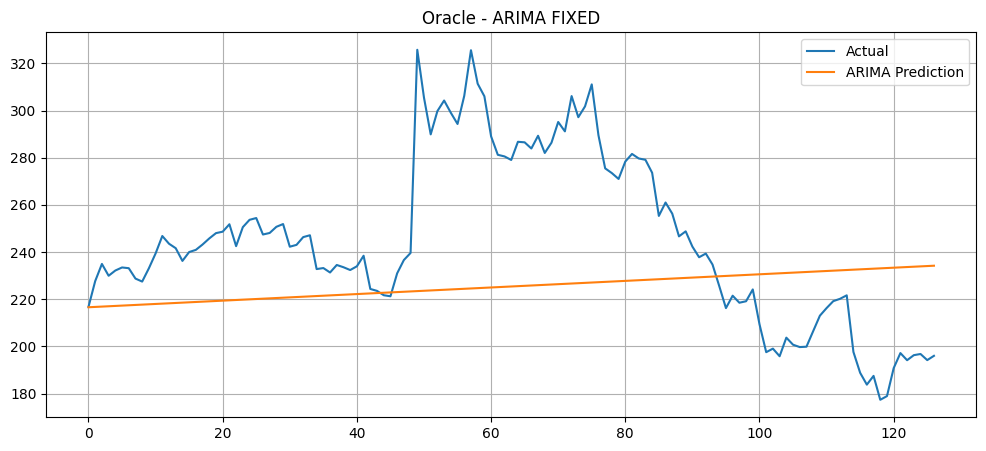

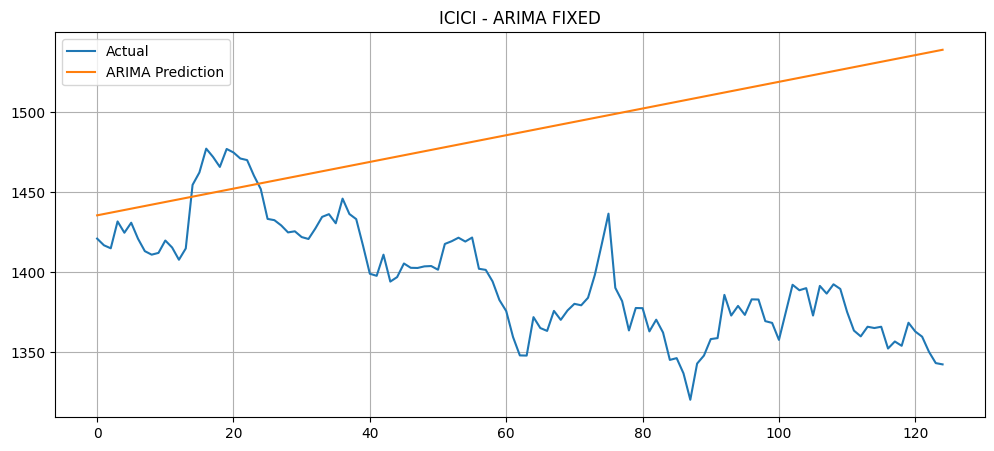

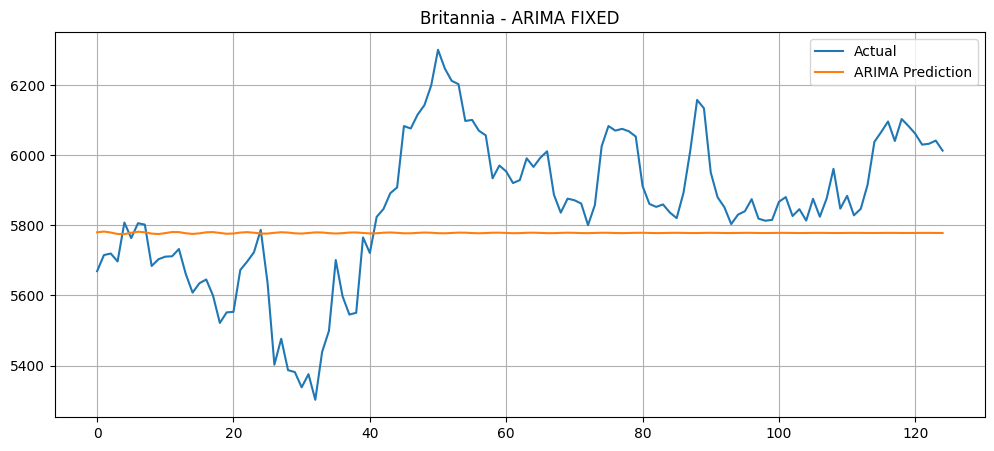

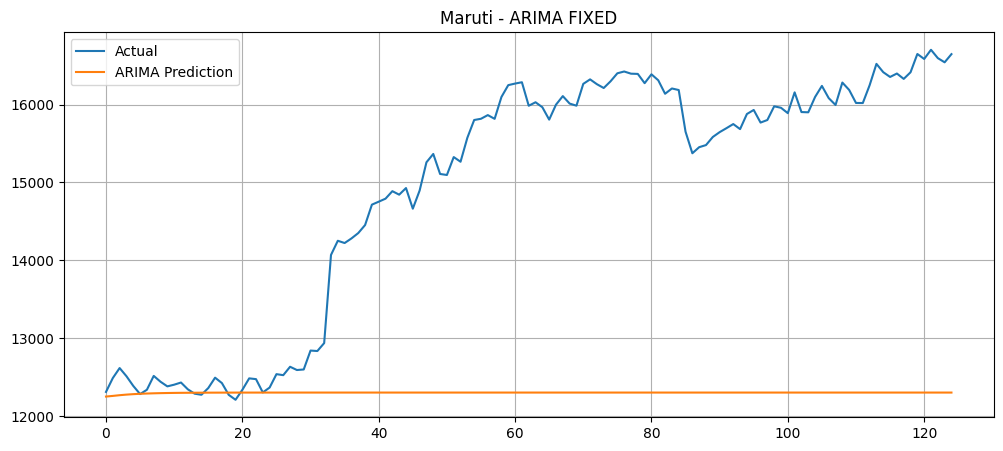

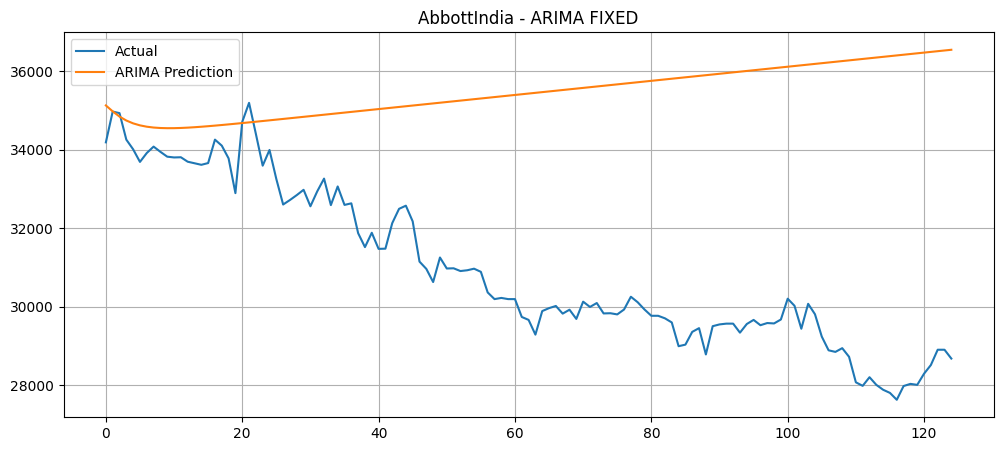

In [56]:
for name in test_data.keys():

    test_close = test_data[name]["Close"].values
    preds = arima_predictions[name]

    # align lengths safely
    min_len = min(len(test_close), len(preds))

    test_close = test_close[:min_len]
    preds = preds[:min_len]

    x = np.arange(min_len)

    plt.figure(figsize=(12,5))

    plt.plot(x, test_close, label="Actual")
    plt.plot(x, preds, label="ARIMA Prediction")

    plt.legend()
    plt.grid(True)
    plt.title(f"{name} - ARIMA FIXED")
    plt.show()

In [54]:
print("ARIMA KEYS:")
print(list(arima_predictions.keys()))

print("\nTEST DATA KEYS:")
print(list(test_data.keys()))

ARIMA KEYS:
['Oracle', 'ICICI', 'Britannia', 'Maruti', 'AbbottIndia']

TEST DATA KEYS:
['Oracle', 'ICICI', 'Britannia', 'Maruti', 'AbbottIndia']


In [57]:
for name in arima_predictions.keys():

    print("\n", name)

    preds = np.array(arima_predictions[name]).reshape(-1)

    print("Pred min:", preds.min())
    print("Pred max:", preds.max())

    print("Actual min:", test_data[name]["Close"].min())
    print("Actual max:", test_data[name]["Close"].max())


 Oracle
Pred min: 216.59804812375435
Pred max: 234.2065978007872
Actual min: Ticker
ORCL    177.370026
dtype: float64
Actual max: Ticker
ORCL    325.759308
dtype: float64

 ICICI
Pred min: 1435.5632825598618
Pred max: 1538.9381520139773
Actual min: Ticker
ICICIBANK.NS    1320.400024
dtype: float64
Actual max: Ticker
ICICIBANK.NS    1477.201782
dtype: float64

 Britannia
Pred min: 5775.020963561896
Pred max: 5782.223751118487
Actual min: Ticker
BRITANNIA.NS    5302.5
dtype: float64
Actual max: Ticker
BRITANNIA.NS    6300.5
dtype: float64

 Maruti
Pred min: 12249.37487623821
Pred max: 12300.553981001209
Actual min: Ticker
MARUTI.NS    12207.869141
dtype: float64
Actual max: Ticker
MARUTI.NS    16703.0
dtype: float64

 AbbottIndia
Pred min: 34549.664489360206
Pred max: 36547.508003101444
Actual min: Ticker
ABBOTINDIA.NS    27630.0
dtype: float64
Actual max: Ticker
ABBOTINDIA.NS    35195.0
dtype: float64


In [60]:
lstm_models = {}

for name in X_train_data.keys():

    model = Sequential()

    model.add(LSTM(64, return_sequences=True, input_shape=(60, 3)))
    model.add(LSTM(32))
    model.add(Dense(16, activation="relu"))
    model.add(Dense(1))

    model.compile(optimizer="adam", loss="mse")

    lstm_models[name] = model

print("LSTM models recreated successfully")

LSTM models recreated successfully


In [61]:
lstm_history = {}
lstm_predictions = {}

for name in X_train_data.keys():

    print("\n==============================")
    print(f"Training LSTM for {name}")
    print("==============================")

    model = lstm_models[name]

    X_train = X_train_data[name]
    y_train = y_train_data[name]

    X_test = X_test_data[name]
    y_test = y_test_data[name]

    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1
    )

    lstm_history[name] = history

    # Predictions
    preds = model.predict(X_test)
    lstm_predictions[name] = preds.flatten()


Training LSTM for Oracle
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0234 - val_loss: 0.0514
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0025 - val_loss: 0.0539
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0028 - val_loss: 0.0418
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0018 - val_loss: 0.0321
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0014 - val_loss: 0.0236
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0013 - val_loss: 0.0228
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0012 - val_loss: 0.0281
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0013 - val_loss: 0.0188
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0011 - val_loss: 0.0274
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 9.7085e-04 - val_loss: 0.0403
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step

Training LSTM for ICICI
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - lo

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step

Training LSTM for Maruti
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0189 - val_loss: 0.0568
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0030 - val_loss: 0.0464
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0026 - val_loss: 0.0300
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0025 - val_loss: 0.0372
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0022 - val_loss: 0.0341
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0021 - val_loss: 0.0352
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0021 - val_loss: 0.0154
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0018 - val_loss: 0.0181
Epoch 9/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0016 - val_loss: 0.0305
Epoch 10/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0017 - val_loss: 0.0140
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step

Training LSTM for AbbottIndia
Epoch 1/10
33/

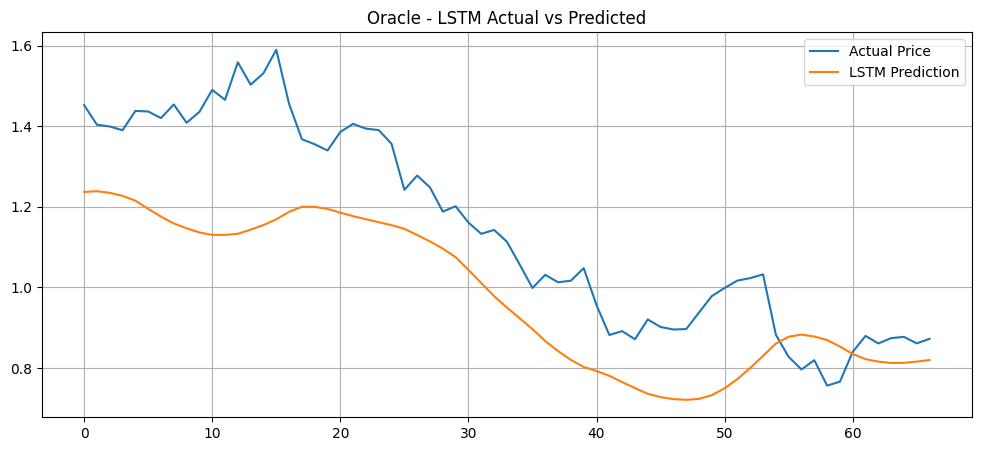

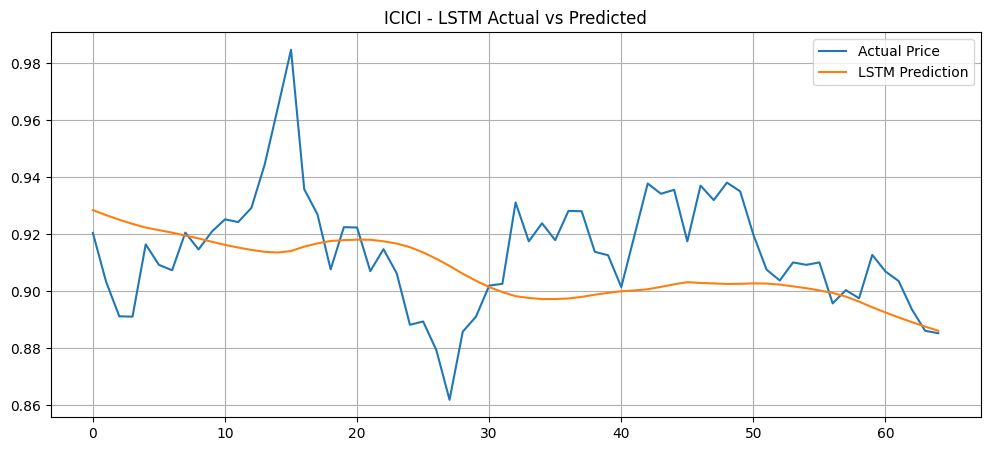

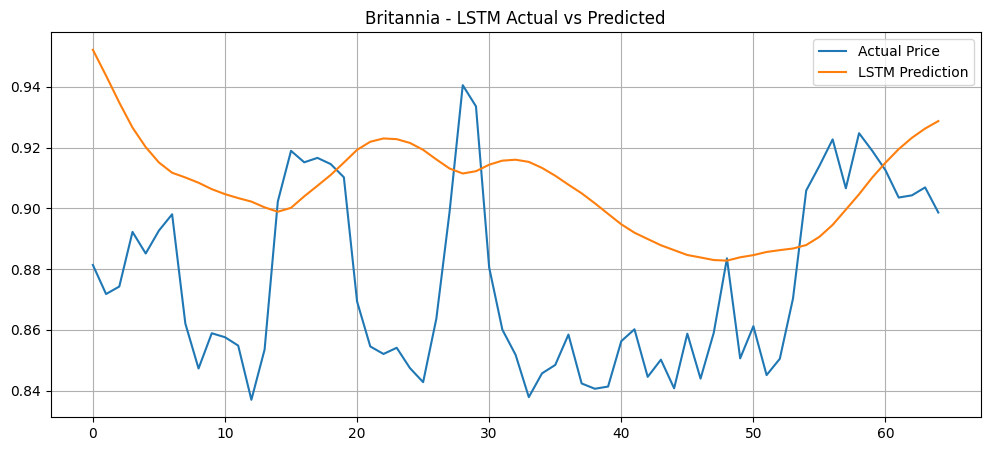

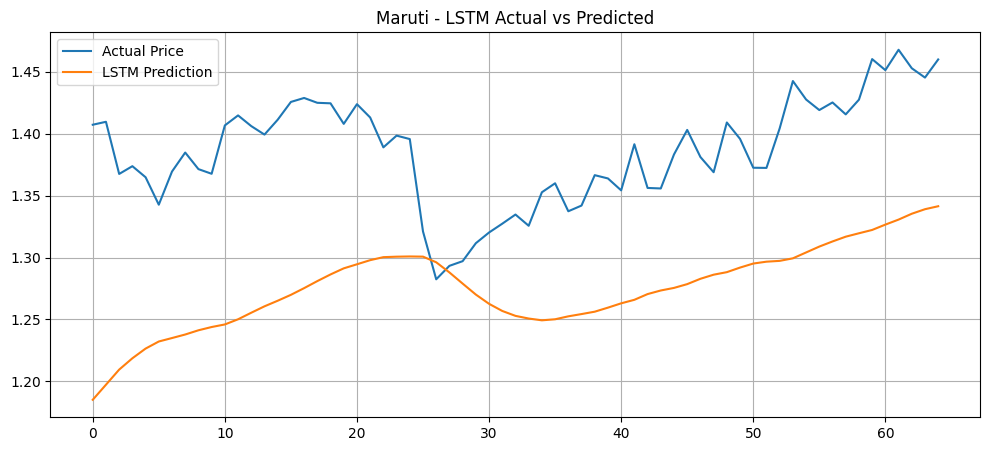

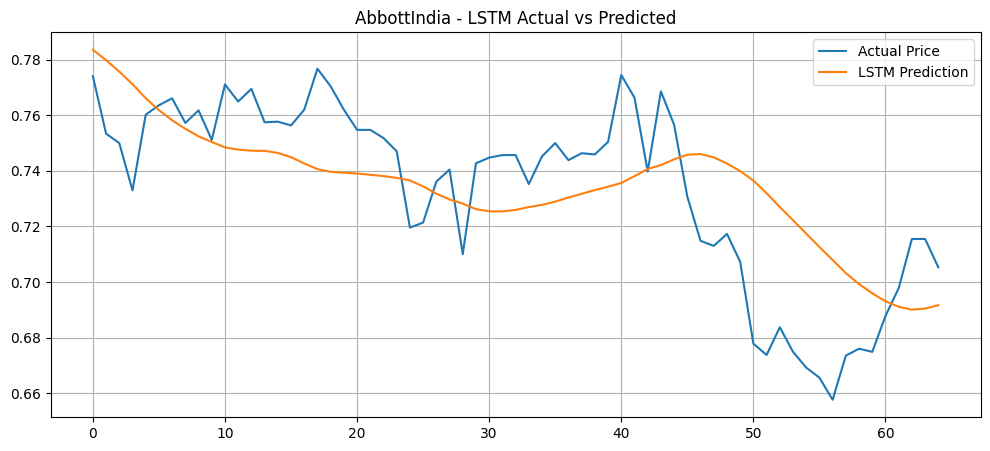

In [62]:
for name in X_test_data.keys():

    y_test = y_test_data[name]
    preds = lstm_predictions[name]

    plt.figure(figsize=(12,5))

    plt.plot(y_test, label="Actual Price")
    plt.plot(preds, label="LSTM Prediction")

    plt.title(f"{name} - LSTM Actual vs Predicted")
    plt.legend()
    plt.grid(True)
    plt.show()

In [63]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

lstm_metrics = {}

for name in y_test_data.keys():

    y_test = y_test_data[name]
    preds = lstm_predictions[name]

    # reshape safety
    y_test = np.array(y_test).reshape(-1)
    preds = np.array(preds).reshape(-1)

    # metrics
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    lstm_metrics[name] = {"RMSE": rmse, "MAE": mae}

    print("\n==============================")
    print(name)
    print("RMSE:", rmse)
    print("MAE :", mae)


Oracle
RMSE: 0.20079253862144425
MAE : 0.17772164503697108

ICICI
RMSE: 0.022447972763407126
MAE : 0.017390612508894777

Britannia
RMSE: 0.043873869520723995
MAE : 0.03799647970885902

Maruti
RMSE: 0.11839224938001697
MAE : 0.1113556438192984

AbbottIndia
RMSE: 0.02515313776415361
MAE : 0.02114730357302133


In [64]:
gru_models = {}

for name in X_train_data.keys():

    model = Sequential()

    model.add(GRU(64, return_sequences=True, input_shape=(60, 3)))
    model.add(GRU(32))

    model.add(Dense(16, activation="relu"))
    model.add(Dense(1))

    model.compile(optimizer="adam", loss="mse")

    gru_models[name] = model

    print("\n==============================")
    print(f"GRU Model Built for {name}")
    model.summary()


GRU Model Built for Oracle


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,201 (90.63 KB)

 Trainable params: 23,201 (90.63 KB)

...

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_8 (GRU)                     │ (None, 60, 64)         │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,201 (90.63 KB)

 Trainable params: 23,201 (90.63 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
gru_history = {}
gru_predictions = {}

for name in X_train_data.keys():

    print("\n==============================")
    print(f"Training GRU for {name}")
    print("==============================")

    model = gru_models[name]

    X_train = X_train_data[name]
    y_train = y_train_data[name]

    X_test = X_test_data[name]
    y_test = y_test_data[name]

    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1
    )

    gru_history[name] = history

    preds = model.predict(X_test)
    gru_predictions[name] = preds.flatten()


Training GRU for Oracle
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.0207 - val_loss: 0.0265
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0020 - val_loss: 0.0222
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0015 - val_loss: 0.0171
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0012 - val_loss: 0.0116
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 9.8375e-04 - val_loss: 0.0103
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 8.1373e-04 - val_loss: 0.0073
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 6.9197e-04 - val_loss: 0.0062
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 6.2408e-04 - val_loss: 0.0052
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 5.4315e-04 - val_loss: 0.0074
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 5.1556e-04 - val_loss: 0.0067
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step

Training GRU for ICICI
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━

In [66]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

gru_metrics = {}

for name in y_test_data.keys():

    y_test = np.array(y_test_data[name]).reshape(-1)
    preds = np.array(gru_predictions[name]).reshape(-1)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    gru_metrics[name] = {"RMSE": rmse, "MAE": mae}

    print("\n==============================")
    print(name)
    print("RMSE:", rmse)
    print("MAE :", mae)


Oracle
RMSE: 0.082091777740739
MAE : 0.06675892239754762

ICICI
RMSE: 0.01677136046683162
MAE : 0.012903021058027306

Britannia
RMSE: 0.024235764356284613
MAE : 0.019252181648372325

Maruti
RMSE: 0.11566492992999915
MAE : 0.11246840649139642

AbbottIndia
RMSE: 0.024790116557942398
MAE : 0.01986541271545068


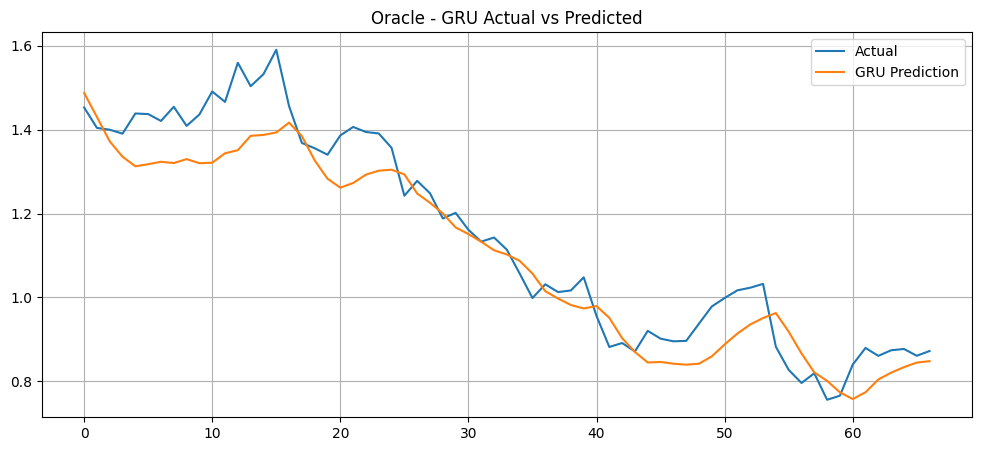

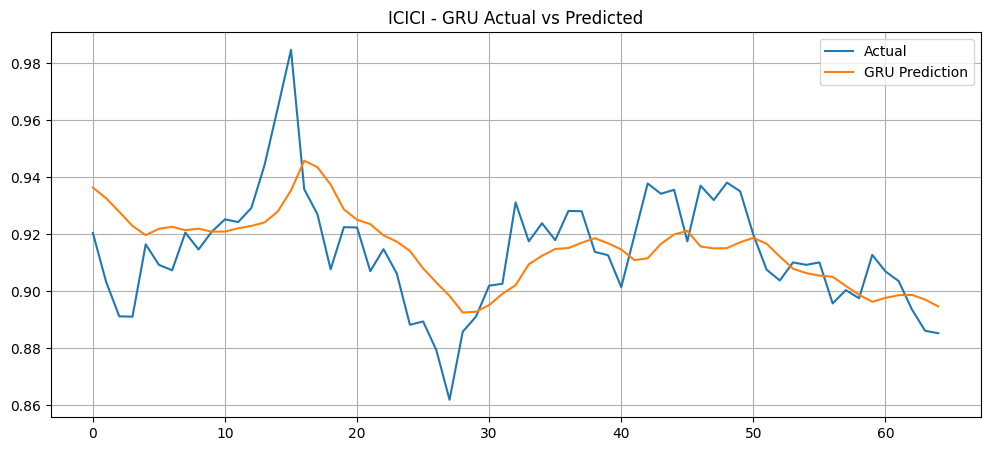

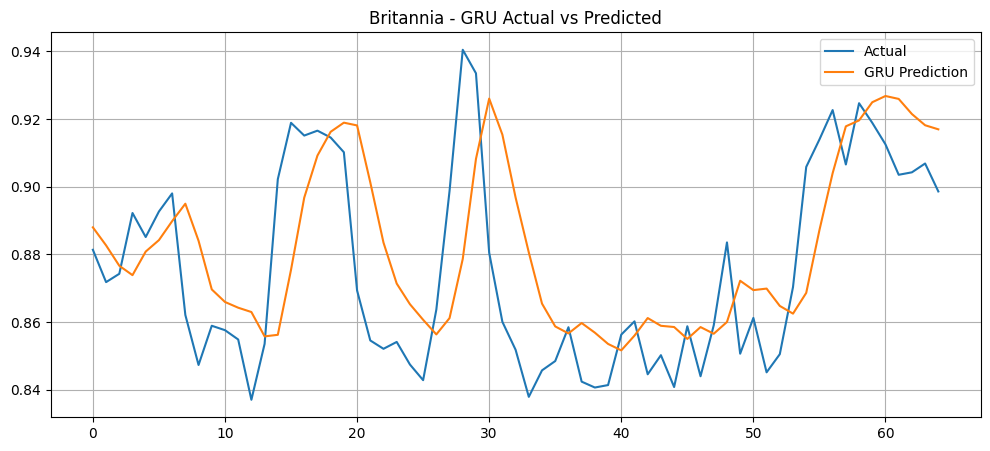

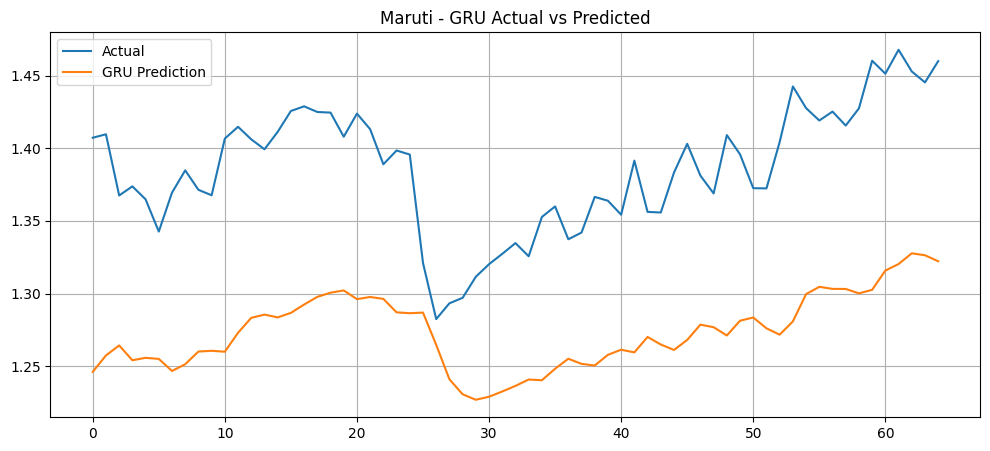

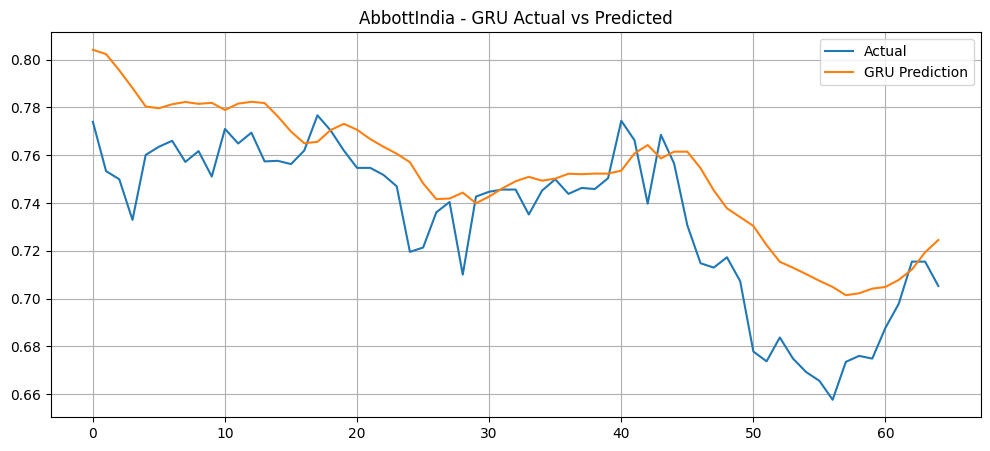

In [67]:
for name in X_test_data.keys():

    y_test = y_test_data[name]
    preds = gru_predictions[name]

    plt.figure(figsize=(12,5))

    plt.plot(y_test, label="Actual")
    plt.plot(preds, label="GRU Prediction")

    plt.title(f"{name} - GRU Actual vs Predicted")
    plt.legend()
    plt.grid(True)
    plt.show()

In [68]:
comparison = []

for name in lstm_metrics.keys():

    comparison.append([
        name,
        arima_predictions[name].shape[0] if name in arima_predictions else None,
        lstm_metrics[name]["RMSE"],
        gru_metrics[name]["RMSE"]
    ])

df_compare = pd.DataFrame(comparison, columns=["Stock", "ARIMA_len", "LSTM_RMSE", "GRU_RMSE"])

df_compare

,Stock,ARIMA_len,LSTM_RMSE,GRU_RMSE
0,Oracle,127,0.200793,0.082092
1,ICICI,125,0.022448,0.016771
2,Britannia,125,0.043874,0.024236
3,Maruti,125,0.118392,0.115665
4,AbbottIndia,125,0.025153,0.024790


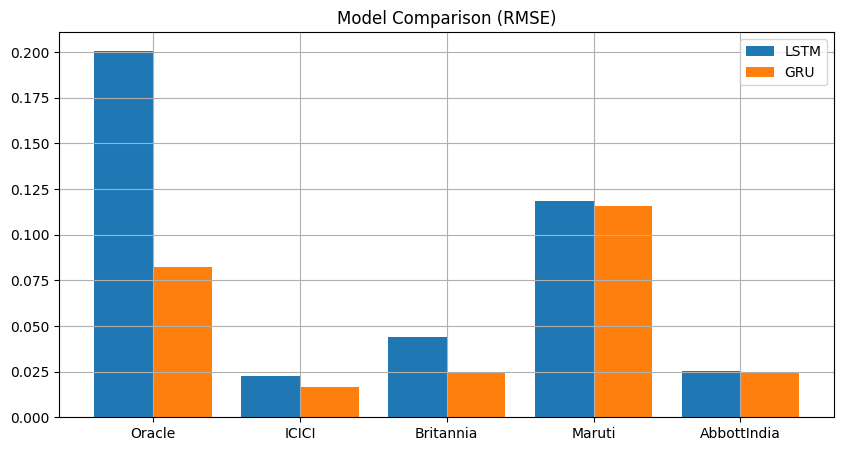

In [69]:
plt.figure(figsize=(10,5))

x = np.arange(len(df_compare["Stock"]))

plt.bar(x - 0.2, df_compare["LSTM_RMSE"], width=0.4, label="LSTM")
plt.bar(x + 0.2, df_compare["GRU_RMSE"], width=0.4, label="GRU")

plt.xticks(x, df_compare["Stock"])
plt.title("Model Comparison (RMSE)")
plt.legend()
plt.grid(True)
plt.show()

In [70]:
def predict_future(model, last_sequence, days=5):

    future_preds = []

    current_seq = last_sequence.copy()

    for _ in range(days):

        pred = model.predict(current_seq.reshape(1, 60, 3))[0][0]
        future_preds.append(pred)

        # shift sequence
        new_row = np.array([pred, pred, pred])  # simplified approximation

        current_seq = np.vstack([current_seq[1:], new_row])

    return future_preds

In [71]:
future_predictions = {}

for name in X_test_data.keys():

    model = lstm_models[name]

    last_seq = X_test_data[name][-1]

    preds = predict_future(model, last_seq, days=5)

    future_predictions[name] = preds

    print("\n==============================")
    print(name)
    print("Next 5 day predictions:", preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

Oracle
Next 5 day predictions: [np.float32(0.81964797), np.float32(0.81820226), np.float32(0.8163065), np.float32(0.8147787), np.float32(0.8141156)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

ICICI
Next 5 day predictions: [np.float32(0.8861509), np.float32(0.8908706), np.float32(0.89604723), np.float32(0.90125364), np.float32(0.9061892)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Britannia
Next 5 day predictions: [np.float32(0.92869693), np.float32(0.93400115), np.float32(0.93771815), np.float32(0.9401561)

In [72]:
import yfinance as yf

live_prices = {}

for name, ticker in stocks.items():

    data = yf.Ticker(ticker).history(period="1d")

    live_price = data["Close"].values[-1]

    live_prices[name] = live_price

    print(name, "Live Price:", live_price)

Oracle Live Price: 192.0800018310547
ICICI Live Price: 1264.300048828125
Britannia Live Price: 5331.5
Maruti Live Price: 12987.0
AbbottIndia Live Price: 27830.0


In [74]:
lstm_predictions_real = {}

for name in lstm_predictions.keys():

    preds = np.array(lstm_predictions[name]).reshape(-1, 1)

    scaler = scalers[name]

    # IMPORTANT: rebuild full 3-feature dummy
    dummy = np.zeros((len(preds), 3))
    dummy[:, 0] = preds[:, 0]

    inv = scaler.inverse_transform(dummy)

    lstm_predictions_real[name] = inv[:, 0]

print("Inverse transform complete")

Inverse transform complete


In [75]:
comparison_table = []

for name in stocks.keys():

    predicted = lstm_predictions_real[name][-1]
    actual = live_prices[name]

    error_pct = abs(predicted - actual) / actual * 100

    comparison_table.append([name, predicted, actual, error_pct])

df_final = pd.DataFrame(
    comparison_table,
    columns=["Stock", "Predicted", "Live Price", "Error %"]
)

df_final

,Stock,Predicted,Live Price,Error %
0,Oracle,187.550127,192.080002,2.358327
1,ICICI,1343.326162,1264.300049,6.250582
2,Britannia,6116.775902,5331.500000,14.728986
3,Maruti,15797.117603,12987.000000,21.637927
4,AbbottIndia,28379.621939,27830.000000,1.974926


In [76]:
gru_predictions_real = {}

for name in gru_predictions.keys():

    preds = np.array(gru_predictions[name]).reshape(-1, 1)

    scaler = scalers[name]

    dummy = np.zeros((len(preds), 3))
    dummy[:, 0] = preds[:, 0]

    inv = scaler.inverse_transform(dummy)

    gru_predictions_real[name] = inv[:, 0]

In [77]:
y_test_real = {}

for name in y_test_data.keys():

    y = np.array(y_test_data[name]).reshape(-1, 1)

    scaler = scalers[name]

    dummy = np.zeros((len(y), 3))
    dummy[:, 0] = y[:, 0]

    inv = scaler.inverse_transform(dummy)

    y_test_real[name] = inv[:, 0]

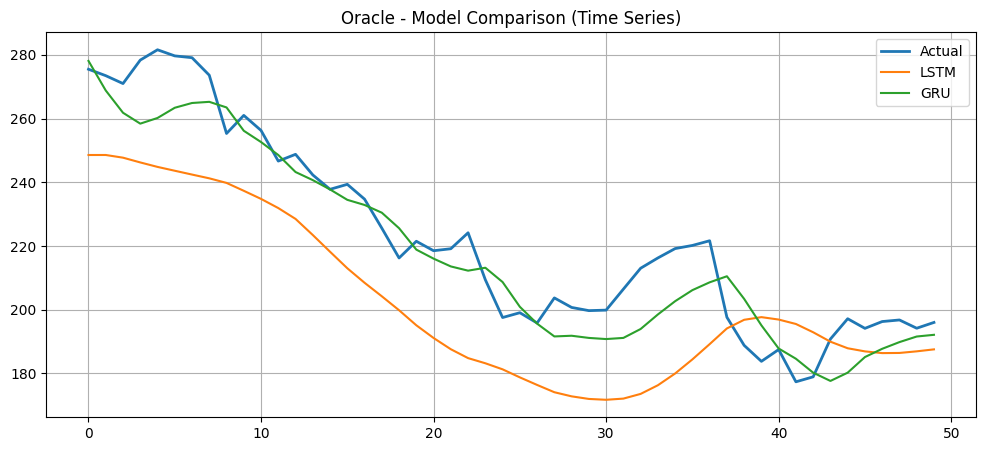

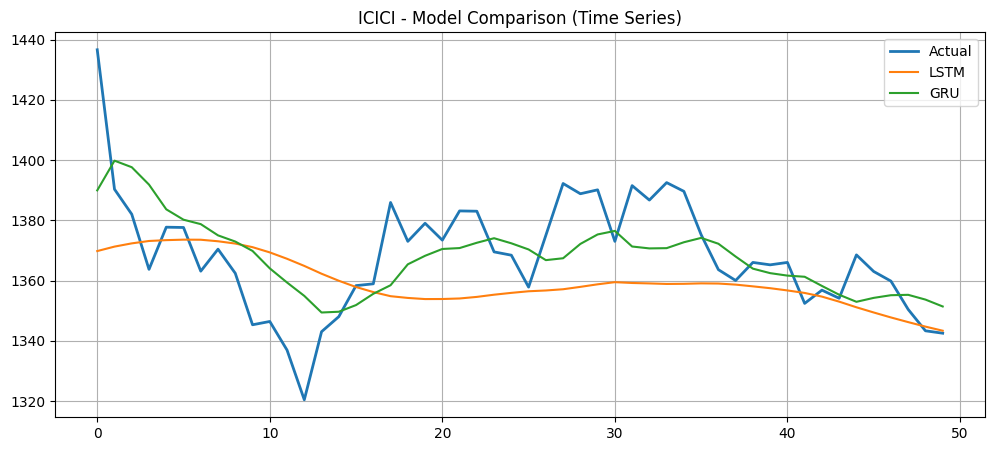

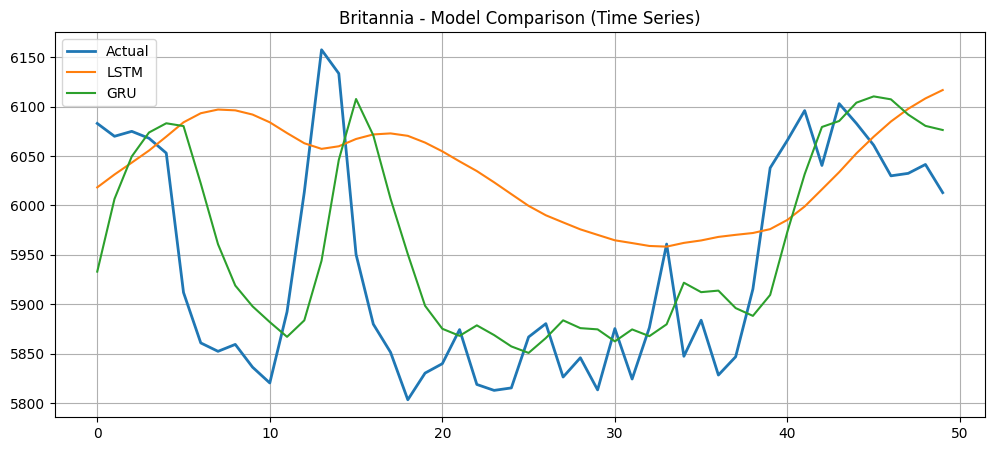

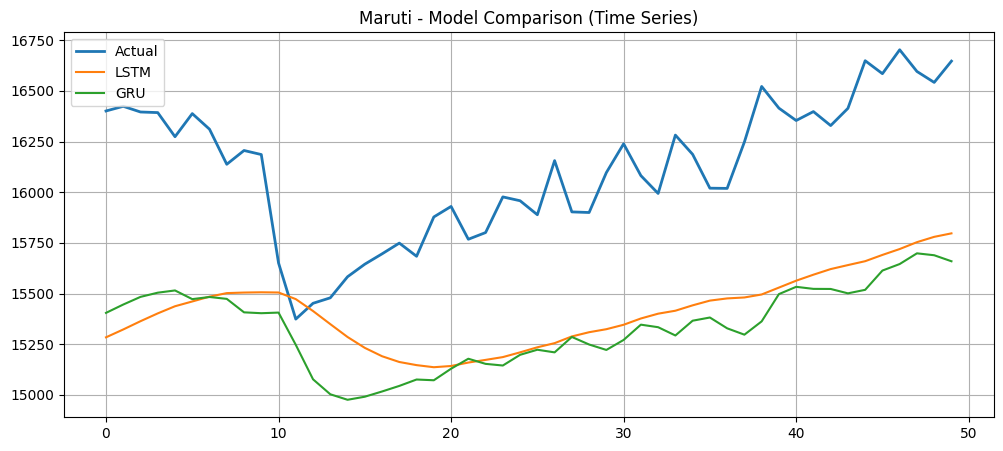

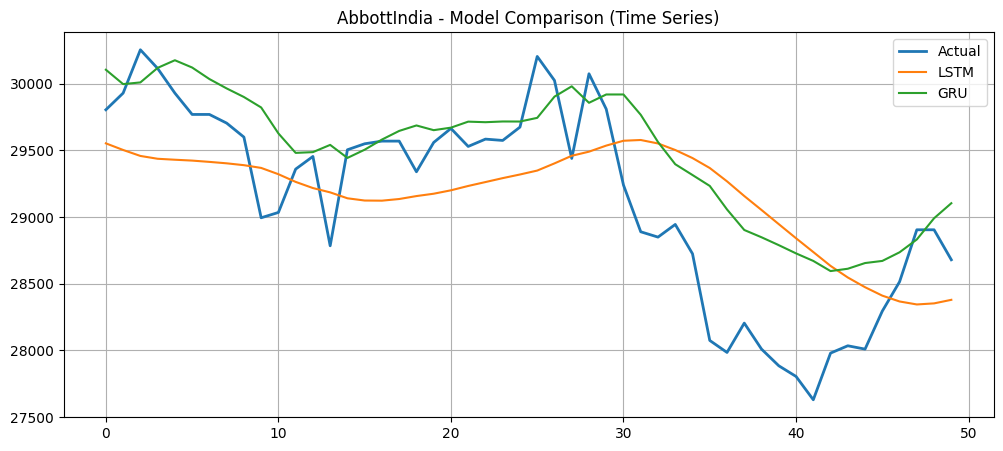

In [78]:
for name in stocks.keys():

    plt.figure(figsize=(12,5))

    actual_series = y_test_real[name][-50:]   # last 50 points
    lstm_series = lstm_predictions_real[name][-50:]
    gru_series = gru_predictions_real[name][-50:]

    x = np.arange(len(actual_series))

    plt.plot(x, actual_series, label="Actual", linewidth=2)
    plt.plot(x, lstm_series, label="LSTM")
    plt.plot(x, gru_series, label="GRU")

    plt.title(f"{name} - Model Comparison (Time Series)")
    plt.legend()
    plt.grid(True)
    plt.show()